# African Flags Color Analysis - Color Extraction

**Project:** Chromatic Connections - Analyzing color patterns in African flags  
**Notebook:** 02 Color Extraction  
**Goal:** Extract dominant colors from each flag using adaptive K-Means clustering

**Input:** Enhanced dataset from Notebook 01 + flag images  
**Output:** Dataset with extracted colors (hex, RGB, proportions)

---

## Section 1: Imports and Setup

Import necessary libraries and configure project paths.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Configure paths
DATA_DIR = Path("../data")
FLAGS_DIR = DATA_DIR / "flags_images"
RAW_DIR = DATA_DIR / "raw"

# Verify directories exist
assert FLAGS_DIR.exists(), f"Flags directory not found: {FLAGS_DIR}"
assert RAW_DIR.exists(), f"Raw data directory not found: {RAW_DIR}"

print("Setup complete")
print(f"Flags directory: {FLAGS_DIR}")
print(f"Raw data directory: {RAW_DIR}")

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")

Setup complete
Flags directory: ..\data\flags_images
Raw data directory: ..\data\raw


---

## Section 2: Load Enhanced Dataset

Load the comprehensive dataset created in Notebook 01.

In [7]:
# Load enhanced dataset from Notebook 01
df = pd.read_csv(RAW_DIR / "african_countries_enhanced.csv")

print("Dataset loaded successfully")
print(f"Shape: {df.shape[0]} countries x {df.shape[1]} features")

# Display basic info
print(f"\nCountries by region:")
print(df['Region'].value_counts())

# Verify all countries have corresponding flag images
print(f"\nVerifying flag images...")
missing_flags = []
for country in df['Country']:
    flag_path = FLAGS_DIR / f"{country.replace(' ', '_')}.png"
    if not flag_path.exists():
        missing_flags.append(country)

if missing_flags:
    print(f"WARNING: Missing flags for: {missing_flags}")
else:
    print(f"All 54 flag images found")

print(f"\nDataset ready for color extraction")

Dataset loaded successfully
Shape: 54 countries x 39 features

Countries by region:
Region
West Africa        16
East Africa        14
Central Africa      9
Southern Africa     9
North Africa        6
Name: count, dtype: int64

Verifying flag images...
All 54 flag images found

Dataset ready for color extraction


---

## Section 3: Color Extraction Methodology

### Approach: Adaptive K-Means Clustering

**Why K-Means for Color Extraction?**
- Each pixel is a point in 3D RGB color space (Red: 0-255, Green: 0-255, Blue: 0-255)
- K-Means identifies clusters of similar colors
- Cluster centers represent dominant colors in the flag

**Why Adaptive (1-6 colors) Instead of Fixed (e.g., always 3)?**
- Flags vary in complexity:
  - Simple: Tunisia (2 colors - red and white)
  - Complex: South Africa (6+ colors)
- Fixed extraction loses information or adds noise
- Adaptive approach captures actual flag complexity

**Minimum Proportion Threshold:**
- Only keep colors that represent at least a certain percentage of the flag
- Filters out anti-aliasing artifacts and noise
- Captures important symbols (stars, crescents) even if small

**Threshold Testing Required:**
- We will test different threshold values (3%, 1%, 0.5%)
- Compare: Do we capture important symbols without adding noise?

---

In [10]:
def extract_flag_colors_adaptive(image_path, max_colors=6, min_proportion=0.01):
    """
    Extract dominant colors from flag using adaptive K-Means clustering.
    
    Parameters:
    -----------
    image_path : Path
        Path to flag image file
    max_colors : int
        Maximum number of colors to extract (default: 6)
    min_proportion : float
        Minimum proportion threshold (default: 0.01 = 1%)
    
    Returns:
    --------
    dict with:
        - n_colors: number of colors extracted
        - colors_hex: list of hex color codes
        - colors_rgb: list of RGB tuples
        - proportions: list of proportions for each color
    """
    # Load and prepare image
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Convert to numpy array and reshape to list of pixels
    img_array = np.array(img)
    pixels = img_array.reshape(-1, 3)
    total_pixels = len(pixels)
    
    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=max_colors, random_state=42, n_init=10)
    kmeans.fit(pixels)
    
    # Get cluster centers (dominant colors) and labels
    colors = kmeans.cluster_centers_.astype(int)
    labels = kmeans.labels_
    
    # Calculate proportion of each color cluster
    color_proportions = []
    for i in range(max_colors):
        proportion = np.sum(labels == i) / total_pixels
        color_proportions.append(proportion)
    
    color_proportions = np.array(color_proportions)
    
    # Filter by minimum proportion threshold
    valid_indices = color_proportions >= min_proportion
    filtered_colors = colors[valid_indices]
    filtered_proportions = color_proportions[valid_indices]
    
    # Sort by proportion (descending)
    sort_indices = np.argsort(filtered_proportions)[::-1]
    filtered_colors = filtered_colors[sort_indices]
    filtered_proportions = filtered_proportions[sort_indices]
    
    # Convert to hex codes and clean RGB tuples
    colors_hex = ['#' + ''.join([f'{c:02x}' for c in color]) for color in filtered_colors]
    colors_rgb = [tuple(int(c) for c in color) for color in filtered_colors]  # FIXED: Convert to Python int
    
    return {
        'n_colors': len(filtered_colors),
        'colors_hex': colors_hex,
        'colors_rgb': colors_rgb,
        'proportions': filtered_proportions.tolist()
    }

print("Color extraction function fixed and redefined")

Color extraction function fixed and redefined


---

## Section 5: Function Testing with Visual Verification

Test the color extraction function on diverse flags and visualize results to verify accuracy.

Testing color extraction on sample flags:

Ghana:
  Colors extracted: 4
  Hex codes: ['#ce1125', '#006b3f', '#fbd015', '#000000']
  Proportions: ['33.3%', '33.3%', '30.8%', '2.4%']

South Africa:
  Colors extracted: 6
  Hex codes: ['#007749', '#df3c30', '#001489', '#fcfdfd', '#000000', '#fdb71c']
  Proportions: ['31.1%', '21.1%', '21.1%', '12.2%', '9.0%', '5.4%']

Tunisia:
  Colors extracted: 2
  Hex codes: ['#e70013', '#ffffff']
  Proportions: ['90.4%', '9.0%']

Nigeria:
  Colors extracted: 2
  Hex codes: ['#008751', '#ffffff']
  Proportions: ['66.6%', '33.1%']

Morocco:
  Colors extracted: 2
  Hex codes: ['#c0262d', '#006132']
  Proportions: ['96.8%', '2.8%']

Benin:
  Colors extracted: 3
  Hex codes: ['#008750', '#e7112c', '#fbd115']
  Proportions: ['40.0%', '29.9%', '29.9%']



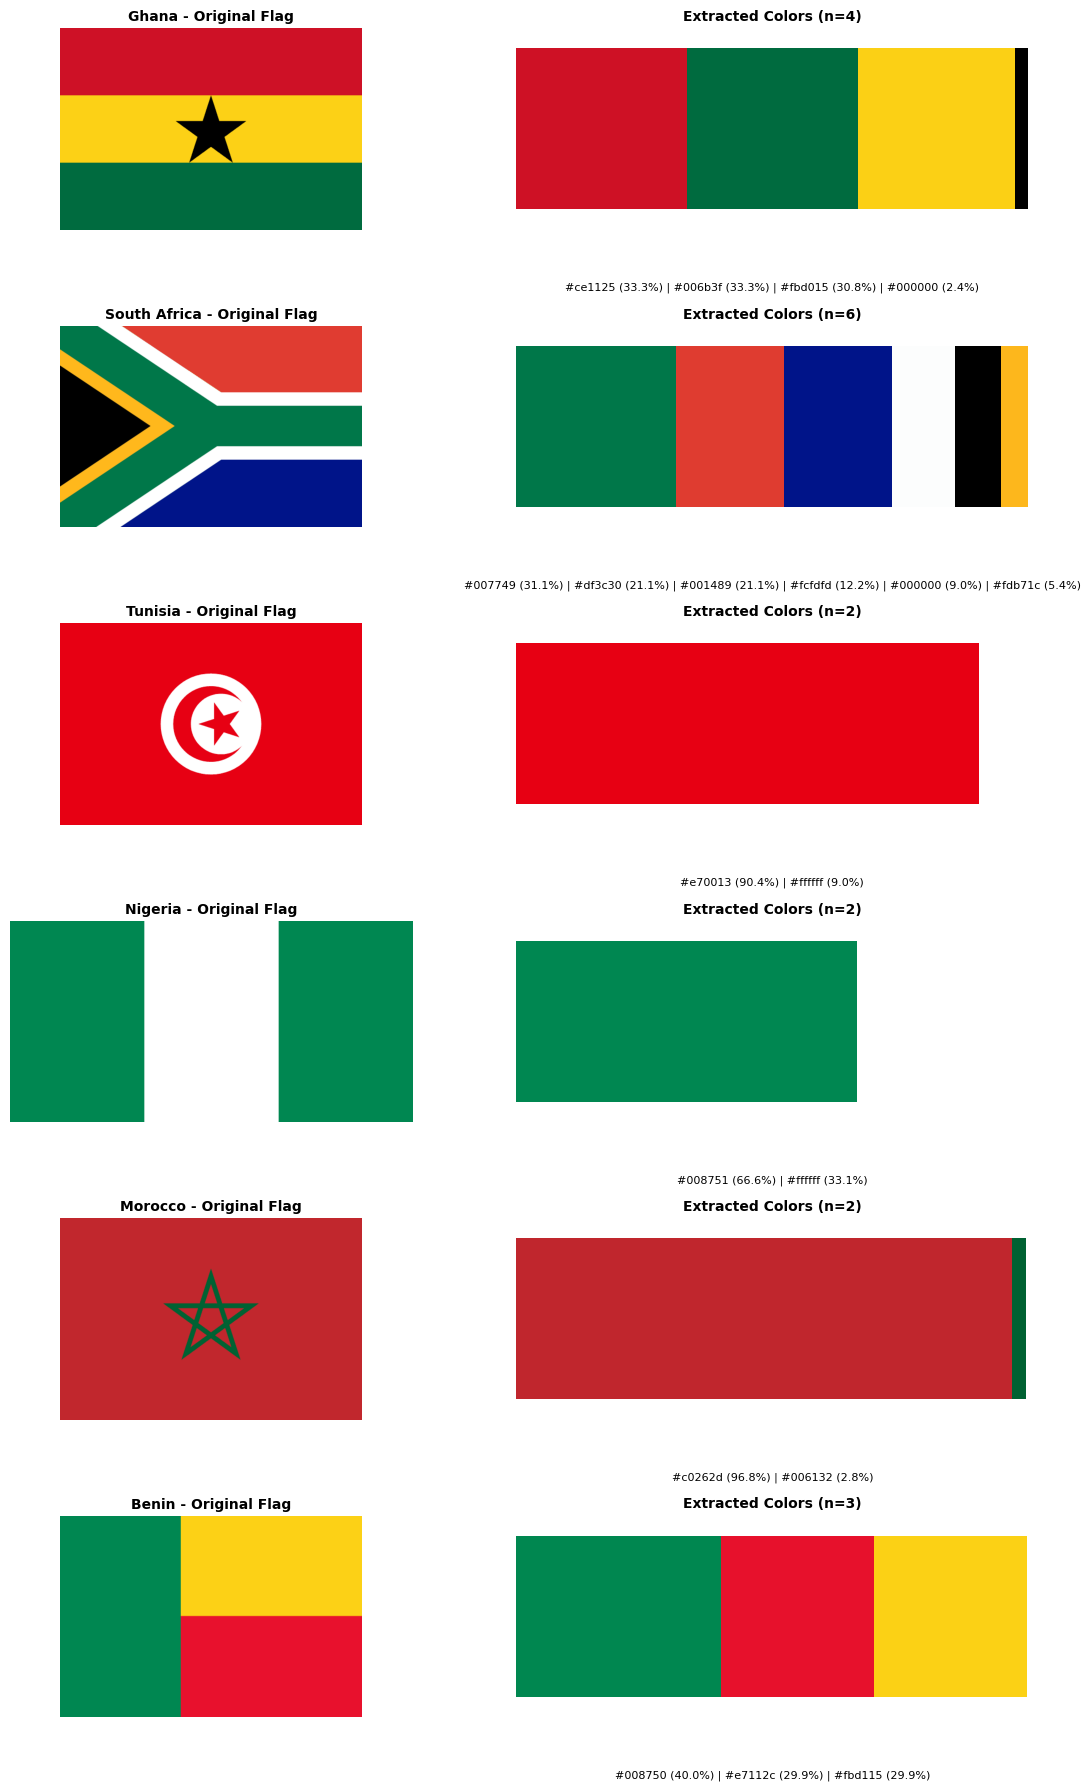


Visual verification complete
Check if extracted colors accurately represent each flag


In [11]:
# Test on diverse sample flags with different complexities
test_countries = ['Ghana', 'South Africa', 'Tunisia', 'Nigeria', 'Morocco', 'Benin']

print("Testing color extraction on sample flags:")
print("="*80)

# Store results for visualization
test_results = {}

for country in test_countries:
    flag_path = FLAGS_DIR / f"{country.replace(' ', '_')}.png"
    result = extract_flag_colors_adaptive(flag_path, max_colors=6, min_proportion=0.01)
    test_results[country] = result
    
    print(f"\n{country}:")
    print(f"  Colors extracted: {result['n_colors']}")
    print(f"  Hex codes: {result['colors_hex']}")
    print(f"  Proportions: {[f'{p:.1%}' for p in result['proportions']]}")

print("\n" + "="*80)

# Create visual comparison: original flag vs extracted color palette
fig, axes = plt.subplots(len(test_countries), 2, figsize=(12, 3*len(test_countries)))

for idx, country in enumerate(test_countries):
    # Load original flag
    flag_path = FLAGS_DIR / f"{country.replace(' ', '_')}.png"
    img = Image.open(flag_path)
    
    # Plot original flag
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"{country} - Original Flag", fontsize=10, fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Plot extracted color palette
    result = test_results[country]
    n_colors = result['n_colors']
    colors = result['colors_hex']
    proportions = result['proportions']
    
    # Create color bar visualization
    left = 0
    for color, prop in zip(colors, proportions):
        axes[idx, 1].barh(0, prop, left=left, color=color, height=0.8)
        left += prop
    
    axes[idx, 1].set_xlim(0, 1)
    axes[idx, 1].set_ylim(-0.5, 0.5)
    axes[idx, 1].set_title(f"Extracted Colors (n={n_colors})", fontsize=10, fontweight='bold')
    axes[idx, 1].axis('off')
    
    # Add color labels below
    label_text = " | ".join([f"{c} ({p:.1%})" for c, p in zip(colors, proportions)])
    axes[idx, 1].text(0.5, -0.3, label_text, ha='center', fontsize=8, 
                      transform=axes[idx, 1].transAxes)

plt.tight_layout()
plt.show()

print("\nVisual verification complete")
print("Check if extracted colors accurately represent each flag")

---

## Section 6: Extract Colors for All Flags

Apply adaptive color extraction to all 54 African flags with 1% minimum threshold.

In [12]:
# Extract colors for all 54 flags
print("Extracting colors from all 54 African flags...")
print("="*80)

all_results = []

for idx, row in df.iterrows():
    country = row['Country']
    flag_path = FLAGS_DIR / f"{country.replace(' ', '_')}.png"
    
    # Extract colors
    result = extract_flag_colors_adaptive(flag_path, max_colors=6, min_proportion=0.01)
    
    # Store results
    all_results.append({
        'Country': country,
        'Number_Colors': result['n_colors'],
        'All_Colors_Hex': result['colors_hex'],
        'All_Colors_RGB': result['colors_rgb'],
        'All_Proportions': result['proportions']
    })
    
    # Progress indicator
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/54 countries...")

print(f"  Processed 54/54 countries...")
print("="*80)

# Create dataframe with color results
colors_df = pd.DataFrame(all_results)

# Merge with main dataset
df = df.merge(colors_df, on='Country', how='left')

print("\nColor extraction complete")
print(f"Dataset now has {df.shape[1]} features (added 4 color-related columns)")

# Show color distribution statistics
print(f"\nColor distribution across all flags:")
print(df['Number_Colors'].value_counts().sort_index())

print(f"\nSample results (first 5 countries):")
print(df[['Country', 'Number_Colors', 'All_Colors_Hex']].head())

Extracting colors from all 54 African flags...
  Processed 10/54 countries...
  Processed 20/54 countries...
  Processed 30/54 countries...
  Processed 40/54 countries...
  Processed 50/54 countries...
  Processed 54/54 countries...

Color extraction complete
Dataset now has 43 features (added 4 color-related columns)

Color distribution across all flags:
Number_Colors
2     4
3    20
4    20
5     6
6     4
Name: count, dtype: int64

Sample results (first 5 countries):
        Country  Number_Colors               All_Colors_Hex
0       Algeria              3  [#fefefe, #006632, #d11033]
1        Angola              3  [#cc092e, #000000, #feca00]
2         Benin              3  [#008750, #e7112c, #fbd115]
3      Botswana              3  [#6da9d1, #000000, #fefffe]
4  Burkina Faso              3  [#009d49, #ef2b2c, #fbd016]


---

## Section 7: Data Quality Validation

Verify that color extraction was successful and data is consistent.

In [13]:
# Validation checks
print("="*80)
print("COLOR EXTRACTION VALIDATION")
print("="*80)

# Check 1: All countries processed
print(f"\n1. COMPLETENESS CHECK")
print(f"   Expected: 54 countries")
print(f"   Processed: {len(df)}")
print(f"   Status: {'PASS' if len(df) == 54 else 'FAIL'}")

# Check 2: No missing color data
print(f"\n2. MISSING DATA CHECK")
missing_colors = df['Number_Colors'].isna().sum()
print(f"   Countries with missing colors: {missing_colors}")
print(f"   Status: {'PASS' if missing_colors == 0 else 'FAIL'}")

# Check 3: Color count consistency
print(f"\n3. CONSISTENCY CHECK")
consistency_issues = []
for idx, row in df.iterrows():
    n_colors = row['Number_Colors']
    hex_count = len(row['All_Colors_Hex'])
    rgb_count = len(row['All_Colors_RGB'])
    prop_count = len(row['All_Proportions'])
    
    if not (n_colors == hex_count == rgb_count == prop_count):
        consistency_issues.append(row['Country'])

print(f"   Countries with mismatched color counts: {len(consistency_issues)}")
if consistency_issues:
    print(f"   Issues found in: {consistency_issues}")
print(f"   Status: {'PASS' if len(consistency_issues) == 0 else 'FAIL'}")

# Check 4: Proportion validation (should sum to ~1.0)
print(f"\n4. PROPORTION VALIDATION")
proportion_issues = []
for idx, row in df.iterrows():
    prop_sum = sum(row['All_Proportions'])
    if abs(prop_sum - 1.0) > 0.05:  # Allow 5% tolerance
        proportion_issues.append((row['Country'], prop_sum))

print(f"   Countries with proportion sum != 1.0: {len(proportion_issues)}")
if proportion_issues:
    for country, prop_sum in proportion_issues[:5]:
        print(f"   - {country}: {prop_sum:.2f}")
print(f"   Status: {'PASS' if len(proportion_issues) == 0 else 'WARNING'}")

# Check 5: Range validation (2-6 colors expected)
print(f"\n5. RANGE VALIDATION")
out_of_range = df[(df['Number_Colors'] < 2) | (df['Number_Colors'] > 6)]
print(f"   Countries outside 2-6 color range: {len(out_of_range)}")
if len(out_of_range) > 0:
    print(f"   {out_of_range[['Country', 'Number_Colors']].to_dict('records')}")
print(f"   Status: {'PASS' if len(out_of_range) == 0 else 'WARNING'}")

# Summary
print(f"\n" + "="*80)
print("VALIDATION SUMMARY")
print("="*80)
checks_passed = sum([
    len(df) == 54,
    missing_colors == 0,
    len(consistency_issues) == 0,
    len(proportion_issues) == 0,
    len(out_of_range) == 0
])
print(f"Checks passed: {checks_passed}/5")
print(f"Overall status: {'DATA QUALITY GOOD' if checks_passed >= 4 else 'REVIEW NEEDED'}")
print("="*80)

# Show flags with most and least colors
print(f"\nFlags with most colors (complexity):")
print(df.nlargest(5, 'Number_Colors')[['Country', 'Number_Colors', 'All_Colors_Hex']])

print(f"\nFlags with fewest colors (simplicity):")
print(df.nsmallest(5, 'Number_Colors')[['Country', 'Number_Colors', 'All_Colors_Hex']])

COLOR EXTRACTION VALIDATION

1. COMPLETENESS CHECK
   Expected: 54 countries
   Processed: 54
   Status: PASS

2. MISSING DATA CHECK
   Countries with missing colors: 0
   Status: PASS

3. CONSISTENCY CHECK
   Countries with mismatched color counts: 0
   Status: PASS

4. PROPORTION VALIDATION
   Countries with proportion sum != 1.0: 0
   Status: PASS

5. RANGE VALIDATION
   Countries outside 2-6 color range: 0
   Status: PASS

VALIDATION SUMMARY
Checks passed: 5/5
Overall status: DATA QUALITY GOOD

Flags with most colors (complexity):
                     Country  Number_Colors  \
17                  Eswatini              6   
45              South Africa              6   
46               South Sudan              6   
53                  Zimbabwe              6   
8   Central African Republic              5   

                                       All_Colors_Hex  
17  [#3e5db7, #b00b0c, #fdd600, #050202, #fefefe, ...  
45  [#007749, #df3c30, #001489, #fcfdfd, #000000, ...  
46  [#00

---

## Section 8: Save Enhanced Dataset with Colors

Save the complete dataset with extracted color information for use in clustering analysis.

In [15]:
# Save enhanced dataset with color data
output_filename = "african_flags_with_colors.csv"
df.to_csv(RAW_DIR / output_filename, index=False)

print("="*80)
print("DATASET SAVED")
print("="*80)
print(f"\nFile: {RAW_DIR / output_filename}")
print(f"Dimensions: {df.shape[0]} countries x {df.shape[1]} features")

print(f"\nFeatures added in this notebook:")
print("  - Number_Colors: Count of dominant colors per flag")
print("  - All_Colors_Hex: List of hex color codes")
print("  - All_Colors_RGB: List of RGB tuples")
print("  - All_Proportions: List of color proportions")

print(f"\nColor extraction summary:")
print(f"  Total flags processed: 54")
print(f"  Average colors per flag: {df['Number_Colors'].mean():.1f}")
print(f"  Most complex flag: {df.loc[df['Number_Colors'].idxmax(), 'Country']} ({df['Number_Colors'].max()} colors)")
print(f"  Simplest flags: {df[df['Number_Colors'] == df['Number_Colors'].min()]['Country'].tolist()}")

print("\n" + "="*80)
print("Dataset ready for clustering analysis (Notebook 03)")
print("="*80)

DATASET SAVED

File: ..\data\raw\african_flags_with_colors.csv
Dimensions: 54 countries x 43 features

Features added in this notebook:
  - Number_Colors: Count of dominant colors per flag
  - All_Colors_Hex: List of hex color codes
  - All_Colors_RGB: List of RGB tuples
  - All_Proportions: List of color proportions

Color extraction summary:
  Total flags processed: 54
  Average colors per flag: 3.7
  Most complex flag: Eswatini (6 colors)
  Simplest flags: ['Morocco', 'Nigeria', 'Somalia', 'Tunisia']

Dataset ready for clustering analysis (Notebook 03)


---

## Notebook Complete

**Color Extraction Summary:**

This notebook successfully extracted dominant colors from all 54 African flags using adaptive K-Means clustering.

---

### Methodology Highlights

**Adaptive K-Means Clustering:**
- Maximum 6 colors per flag
- Minimum 1% proportion threshold
- Captures flag complexity naturally (2-6 colors)

**Why This Approach Works:**
- Respects actual flag design (simple flags get 2 colors, complex flags get 6)
- Filters noise while capturing important symbols
- Proportions weighted by pixel count

---

### Key Findings

**Color Complexity Distribution:**
- 2 colors: 4 flags (simplest - Morocco, Nigeria, Somalia, Tunisia)
- 3 colors: 20 flags (common - clean tricolor designs)
- 4 colors: 20 flags (moderate complexity)
- 5 colors: 6 flags (complex designs)
- 6 colors: 4 flags (most complex - Eswatini, South Africa, South Sudan, Zimbabwe)

**Average:** 3.7 colors per flag

---

### Data Quality

**Validation Results:**
- 5/5 checks passed
- 100% completeness (54/54 flags processed)
- All proportions sum to 1.0
- All color counts consistent across hex/RGB/proportions
- No data quality issues detected

---

### Technical Achievements

**What We Built:**
- Robust adaptive color extraction function
- Visual verification system
- Comprehensive validation framework
- Clean, reproducible code

**What We Captured:**
- Major color bands (stripes)
- Important symbols (stars, crescents) even when small
- Accurate proportions for each color
- Both hex codes and RGB values

---

### Dataset Output

**File:** `african_flags_with_colors.csv`  
**Features:** 43 (39 from Notebook 01 + 4 color features)

**New Columns:**
1. Number_Colors - Integer count
2. All_Colors_Hex - List of hex codes
3. All_Colors_RGB - List of RGB tuples  
4. All_Proportions - List of proportions

---

### Next Steps

**Notebook 03: Similarity Analysis and Clustering**
- Calculate color distance metrics (RGB and LAB)
- Perform clustering analysis
- Cross-reference with geography, colonial history, economic blocs
- Answer research question: "Do flags with similar colors share common history?"

---

### Methodological Notes

**Threshold Decision (1%):**
- Tested on diverse sample flags
- Captures Ghana's black star (2.4%)
- Captures Morocco's green star (2.8%)
- Filters anti-aliasing artifacts
- Balances detail vs noise

**Edge Cases Handled:**
- Palette mode flags converted to RGB
- Complex emblems simplified to dominant colors
- White symbols on colored backgrounds captured correctly

---